# Customer Intelligence System
### Clustering (K-Means, DBSCAN) + Classification (Random Forest, XGBoost) + Ensemble Learning

**Dataset:** [Kaggle — Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)

**Framing note:** This dataset has no target label, so a classifier can't be trained on it directly.
The standard, industry-legitimate way to turn an unsupervised problem into an end-to-end
*Customer Intelligence System* is the **cluster-then-classify** pattern:

1. **Cluster** entities (here: countries; in a CRM: customers) into segments using behavioral/socio-economic features.
2. **Profile & name** each cluster in business-readable terms (e.g. "High-Value", "Growth", "At-Risk").
3. **Train a classifier** (Random Forest, XGBoost) to predict segment membership for **new, unseen** entities —
   so you never have to re-cluster your whole customer base every time someone new signs up.
4. **Ensemble** the classifiers (soft voting) for a more robust, production-grade predictor.

Just rename `country` → `customer_id` and the socio-economic columns → real behavioral features
(recency, frequency, monetary value, engagement, churn signals, etc.) and this notebook works
unchanged on real CRM data.


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              adjusted_rand_score, accuracy_score,
                              precision_recall_fscore_support,
                              classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from scipy import stats

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed -> run: pip install xgboost")

import os

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

os.makedirs("plots", exist_ok=True)

def save_current_fig(filename):
    """Save the current matplotlib figure into ./plots/ before showing it."""
    plt.savefig(os.path.join("plots", filename), dpi=150, bbox_inches="tight")


## 2. Load & Explore the Data

Download `Country-data.csv` from the Kaggle link above and place it in the same folder as this
notebook (or update the path below).

In [2]:
DATA_PATH = "Country-data.csv"  # <-- update if needed

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [4]:
print("Missing values per column:")
df.isnull().sum()


Missing values per column:


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


**What to look for:** confirm there are no missing values (this dataset is clean), and note
the wide range in `income` and `gdpp` — these will likely be the strongest cluster-separating
features.

## 3. Exploratory Data Analysis

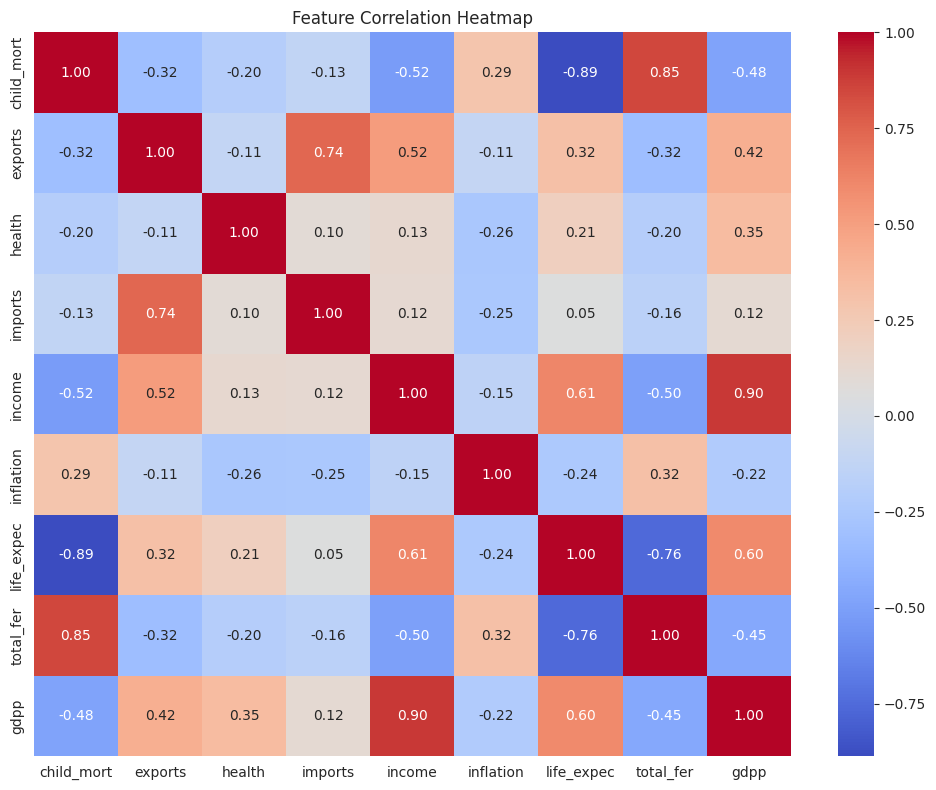

In [5]:
feature_cols = [c for c in df.columns if c != "country"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
save_current_fig("eda_correlation.png")
plt.show()


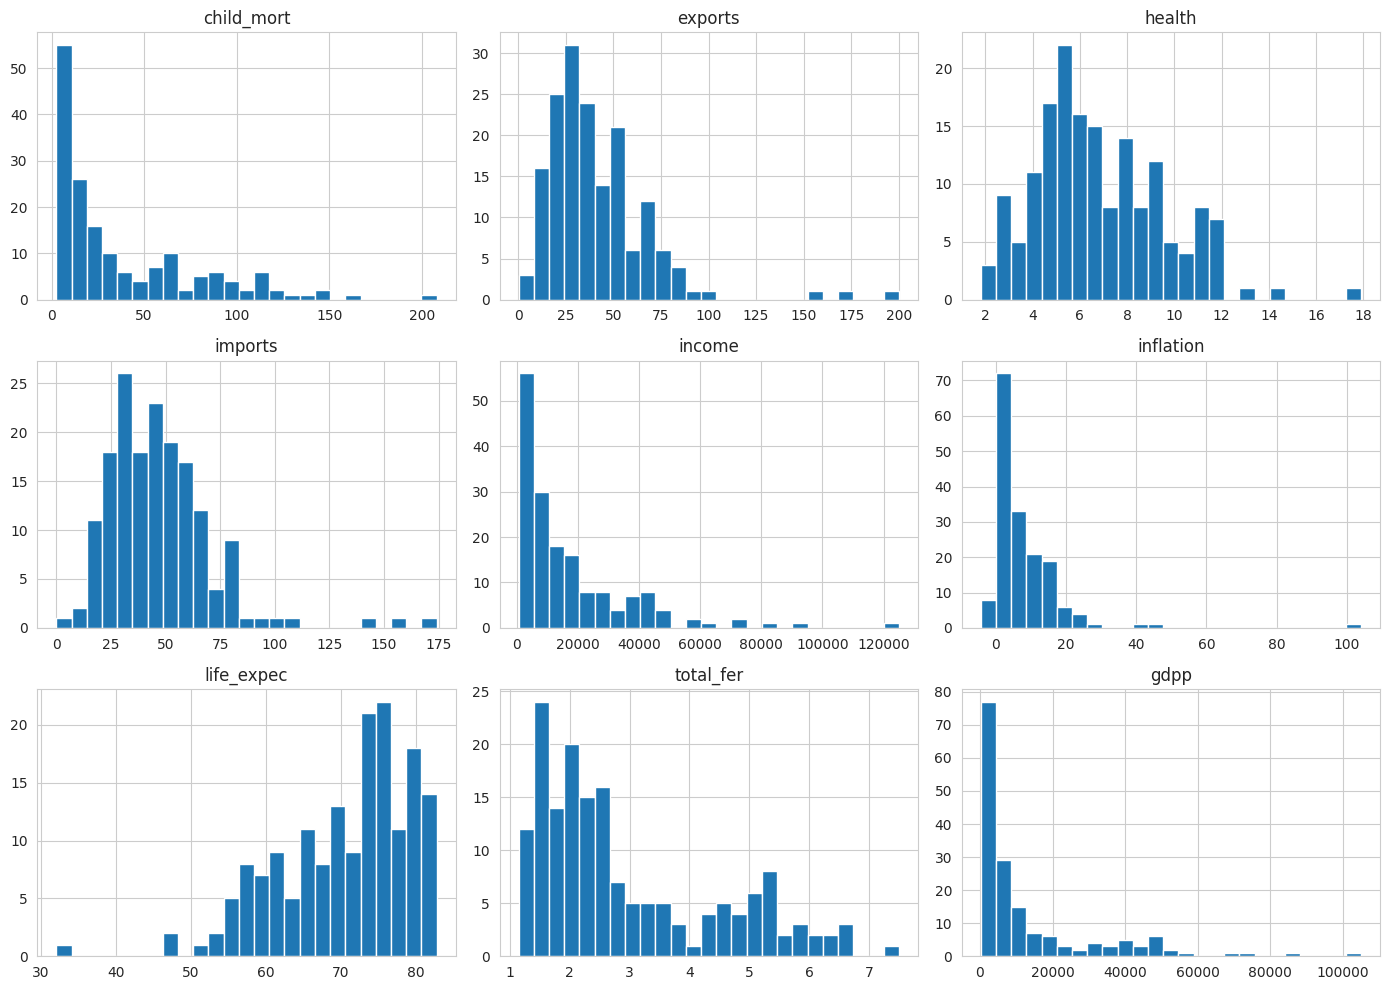

In [6]:
df[feature_cols].hist(figsize=(14, 10), bins=25)
plt.tight_layout()
save_current_fig("eda_distributions.png")
plt.show()


**Interpretation:** `income` and `gdpp` are usually strongly correlated (richer countries earn
more per capita) — expect these two to carry a lot of the clustering signal. `child_mort` typically
correlates *negatively* with `life_expec` and `gdpp`, which makes intuitive sense.

## 4. Preprocessing

All features are on very different scales (inflation is a small percentage, income is in the
thousands), so every distance-based algorithm here (K-Means, DBSCAN, PCA) **requires** scaling
first — otherwise `income` alone would dominate the distance calculation.

In [7]:
X = df[feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature matrix shape:", X_scaled.shape)


Scaled feature matrix shape: (167, 9)


## 5. Clustering — K-Means

We don't guess the number of clusters (*k*) — we let the **elbow method**, **silhouette score**,
and **Davies-Bouldin index** tell us:
- Elbow (inertia): look for the "bend" where adding more clusters stops helping much.
- Silhouette score (higher = better, max 1): measures how well-separated and cohesive clusters are.
- Davies-Bouldin (lower = better): measures cluster similarity/overlap.


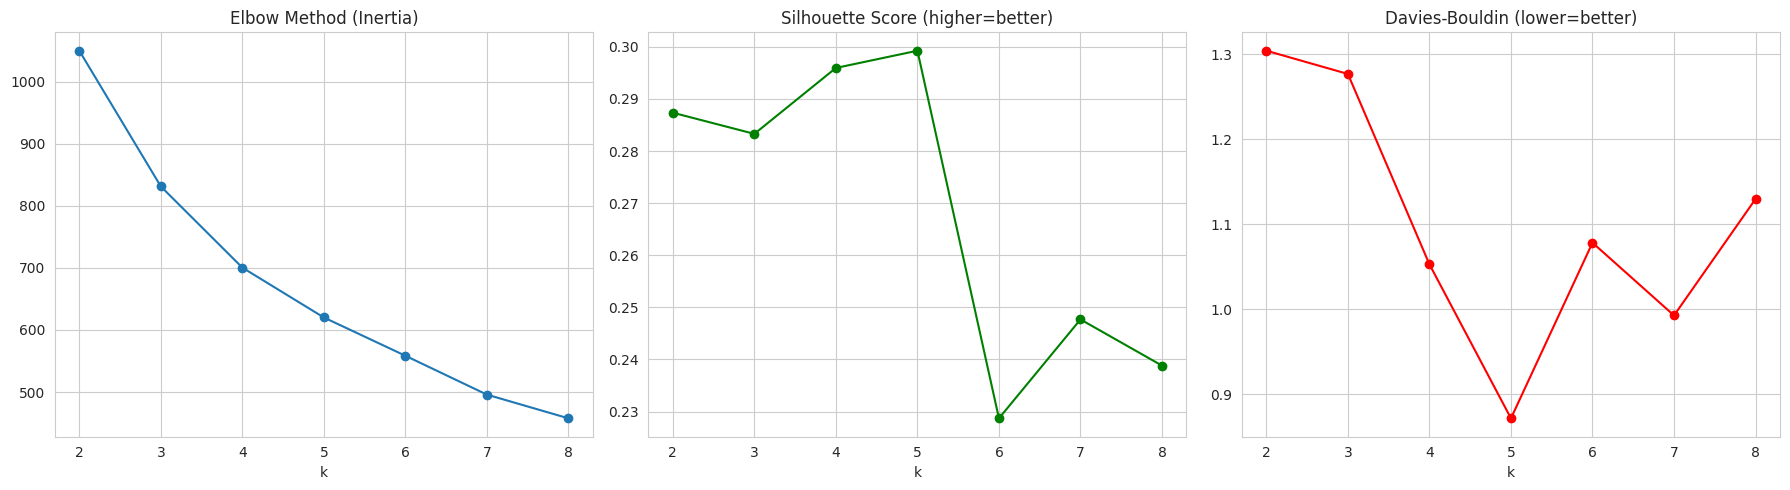

Suggested k (by silhouette): 5


In [8]:
k_range = range(2, 9)
inertias, sil_scores, db_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(list(k_range), inertias, marker="o"); axes[0].set_title("Elbow Method (Inertia)"); axes[0].set_xlabel("k")
axes[1].plot(list(k_range), sil_scores, marker="o", color="green"); axes[1].set_title("Silhouette Score (higher=better)"); axes[1].set_xlabel("k")
axes[2].plot(list(k_range), db_scores, marker="o", color="red"); axes[2].set_title("Davies-Bouldin (lower=better)"); axes[2].set_xlabel("k")
plt.tight_layout()
save_current_fig("kmeans_k_selection.png")
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Suggested k (by silhouette): {best_k}")


In [9]:
km_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
km_labels = km_model.fit_predict(X_scaled)
print(f"K-Means (k={best_k}) silhouette score: {silhouette_score(X_scaled, km_labels):.3f}")

df["segment"] = km_labels


K-Means (k=5) silhouette score: 0.299


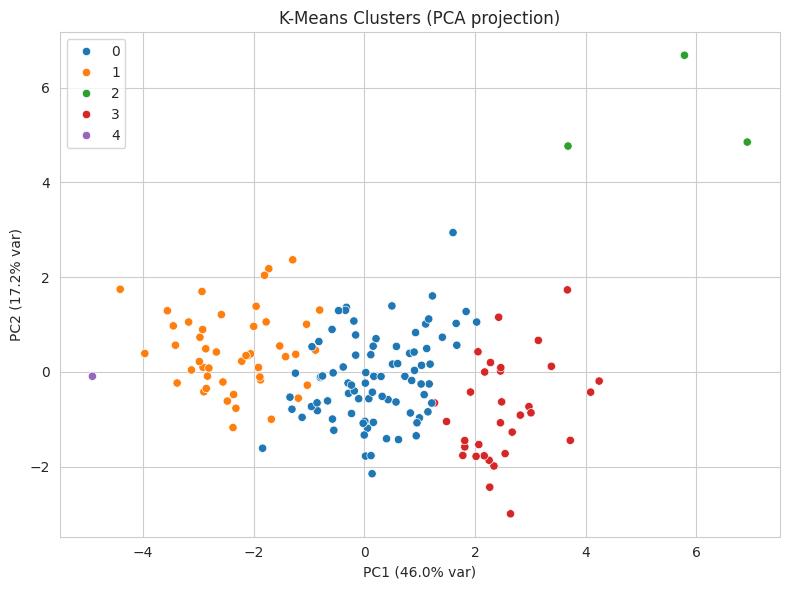

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=km_labels, palette="tab10", legend="full")
plt.title("K-Means Clusters (PCA projection)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout()
save_current_fig("kmeans_clusters.png")
plt.show()


## 6. Clustering — DBSCAN (density-based comparison)

DBSCAN doesn't assume spherical clusters and can flag outliers as "noise" (label `-1`) instead of
forcing them into the nearest cluster. This is useful here because a handful of countries (e.g.
small oil-rich nations) can have distorted GDP-per-capita values that don't fit neatly anywhere.

We first do a small grid search over `eps` and `min_samples` to find reasonable settings.

In [11]:
results = []
for eps in (0.5, 0.8, 1.0, 1.2, 1.5, 2.0):
    for ms in (3, 5, 8, 10):
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).mean()
        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask]) if mask.sum() > 1 else np.nan
        else:
            sil = np.nan
        results.append((eps, ms, n_clusters, noise_pct, sil))

dbscan_grid = pd.DataFrame(results, columns=["eps", "min_samples", "n_clusters", "noise_pct", "silhouette"])
dbscan_grid.sort_values("silhouette", ascending=False).head(10)


,eps,min_samples,n_clusters,noise_pct,silhouette
15,1.2,10,2,0.562874,0.448122
5,0.8,5,3,0.874251,0.440645
9,1.0,5,3,0.562874,0.434453
14,1.2,8,3,0.425150,0.394079
13,1.2,5,3,0.317365,0.385026
8,1.0,3,6,0.431138,0.308836
12,1.2,3,4,0.245509,0.298359
10,1.0,8,3,0.736527,0.286173
4,0.8,3,8,0.670659,0.244870
16,1.5,3,2,0.149701,0.226141


**How to read this table:** pick the row with the highest silhouette score that still has a
reasonable `noise_pct` (under ~20-25%). If every combination pushes noise above 30-40%, that's your
evidence DBSCAN isn't a great *primary* segmentation method for this data — but it's still useful
as an outlier detector, which is exactly how we'll use it below.

DBSCAN found 3 clusters and 53 noise points (31.7%)
DBSCAN silhouette score (excluding noise): 0.385


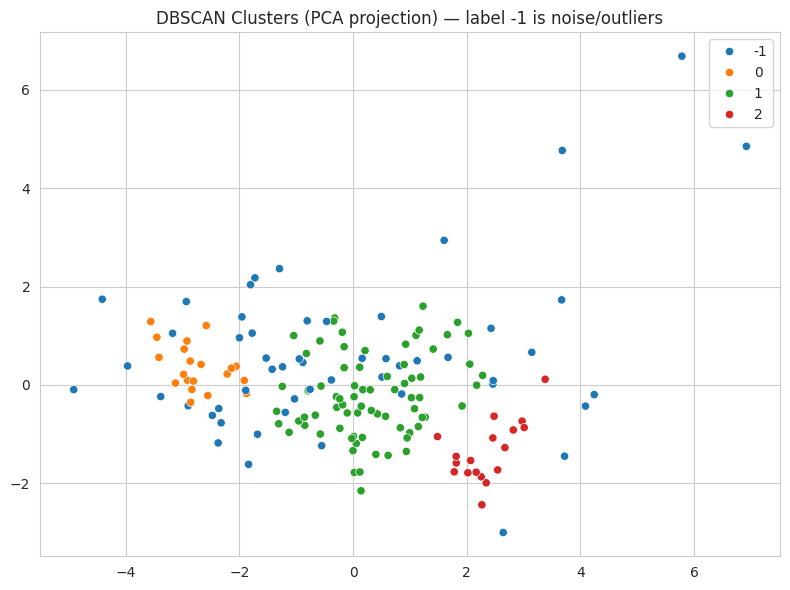

In [12]:
# Update these two values based on the best row from the grid above
DBSCAN_EPS = 1.2
DBSCAN_MIN_SAMPLES = 5

db_model = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
db_labels = db_model.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points ({n_noise/len(db_labels)*100:.1f}%)")

if n_clusters > 1:
    mask = db_labels != -1
    print(f"DBSCAN silhouette score (excluding noise): {silhouette_score(X_scaled[mask], db_labels[mask]):.3f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=db_labels, palette="tab10", legend="full")
plt.title("DBSCAN Clusters (PCA projection) — label -1 is noise/outliers")
plt.tight_layout()
save_current_fig("dbscan_clusters.png")
plt.show()


In [13]:
# Which countries did DBSCAN flag as outliers?
outlier_countries = df.loc[db_labels == -1, "country"].tolist()
print(f"{len(outlier_countries)} countries flagged as outliers by DBSCAN:")
print(outlier_countries)


53 countries flagged as outliers by DBSCAN:
['Angola', 'Bahrain', 'Belarus', 'Belgium', 'Botswana', 'Brunei', 'Burundi', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Haiti', 'Iraq', 'Ireland', 'Jordan', 'Kiribati', 'Kuwait', 'Lao', 'Lesotho', 'Liberia', 'Libya', 'Luxembourg', 'Malta', 'Mauritania', 'Micronesia, Fed. Sts.', 'Moldova', 'Mongolia', 'Myanmar', 'Nigeria', 'Norway', 'Oman', 'Pakistan', 'Qatar', 'Rwanda', 'Saudi Arabia', 'Seychelles', 'Sierra Leone', 'Singapore', 'Solomon Islands', 'South Africa', 'Sudan', 'Switzerland', 'Timor-Leste', 'Togo', 'Tonga', 'Turkmenistan', 'United Arab Emirates', 'United States', 'Venezuela', 'Vietnam', 'Yemen']


## 6b. Do K-Means and DBSCAN agree? (Adjusted Rand Index)

Before trusting the K-Means segments enough to train a classifier on them, it's worth checking
whether DBSCAN — a completely different algorithm with different assumptions — found similar
structure. High agreement is strong evidence the segments reflect real structure in the data, not
just an artifact of K-Means' spherical-cluster assumption.

In [14]:
mask = db_labels != -1
ari = adjusted_rand_score(km_labels[mask], db_labels[mask])
print(f"Adjusted Rand Index (K-Means vs DBSCAN, excluding DBSCAN noise): {ari:.3f}")
print("(1.0 = perfect agreement, 0.0 = random/no agreement)")


Adjusted Rand Index (K-Means vs DBSCAN, excluding DBSCAN noise): 0.835
(1.0 = perfect agreement, 0.0 = random/no agreement)


## 7. Profile & Name the Segments

Turn opaque cluster IDs (0, 1, 2...) into business-readable segment names by ranking clusters on
a key metric (`gdpp` here — swap for `monetary_value`/`CLV` on real customer data).

In [15]:
profile = df.groupby("segment")[feature_cols].mean()
profile


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
segment,,,,,,,,,
0,21.614286,40.976060,6.169048,47.518642,12801.071429,7.618857,73.004762,2.277619,6581.809524
1,90.793617,29.661915,6.462553,43.680851,3870.702128,9.951809,59.212766,4.974043,1900.255319
2,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667
3,5.181250,46.118750,9.088437,40.584375,44021.875000,2.513844,80.081250,1.788437,42118.750000
4,130.000000,25.300000,5.070000,17.400000,5150.000000,104.000000,60.500000,5.840000,2330.000000


In [16]:
means = df.groupby("segment")["gdpp"].mean().sort_values()
ranked_clusters = means.index.tolist()
n = len(ranked_clusters)

if n == 3:
    names = ["Low-Value / At-Risk", "Growth / Developing", "High-Value / Premium"]
elif n == 4:
    names = ["Low-Value / At-Risk", "Emerging", "Growth", "High-Value / Premium"]
else:
    names = [f"Segment {i}" for i in range(n)]

mapping = dict(zip(ranked_clusters, names[:n]))
df["segment_name"] = df["segment"].map(mapping)

print("Segment name mapping:", mapping)
df[["country", "segment", "segment_name"]].sort_values("segment")


Segment name mapping: {1: 'Segment 0', 4: 'Segment 1', 0: 'Segment 2', 3: 'Segment 3', 2: 'Segment 4'}


,country,segment,segment_name
1,Albania,0,Segment 2
2,Algeria,0,Segment 2
5,Argentina,0,Segment 2
4,Antigua and Barbuda,0,Segment 2
6,Armenia,0,Segment 2
...,...,...,...
157,United Arab Emirates,3,Segment 3
145,Switzerland,3,Segment 3
139,Spain,3,Segment 3
135,Slovenia,3,Segment 3


## 8. Classification — Predicting Segment Membership for New/Unseen Entities

This is the step that turns "clustering" into a genuine **Customer Intelligence System**: once we
trust the segments, we train supervised classifiers to predict segment membership from raw
features alone — so a brand-new customer can be scored instantly without re-running clustering on
the entire dataset.

We tune both models with `GridSearchCV` (5-fold CV, scored on weighted F1) rather than using
default hyperparameters.

In [18]:
print("Value counts for segments before split:")
print(df["segment"].value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, df["segment"], test_size=0.2, random_state=RANDOM_STATE
    # Removed stratify=df["segment"] due to single-member class issue
)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Value counts for segments before split:
segment
0    84
1    47
3    32
2     3
4     1
Name: count, dtype: int64
Train size: 133 | Test size: 34


### 8a. Random Forest

In [19]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_grid = GridSearchCV(
    rf,
    param_grid={"max_depth": [4, 6, 8, None], "min_samples_split": [2, 5, 10]},
    cv=5, scoring="f1_weighted", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
print("Best params:", rf_grid.best_params_)

y_pred_rf = rf_best.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best params: {'max_depth': 4, 'min_samples_split': 2}


### 8b. XGBoost

In [20]:
xgb_best = None
if HAS_XGB:
    xgb = XGBClassifier(n_estimators=300, eval_metric="mlogloss", random_state=RANDOM_STATE)
    xgb_grid = GridSearchCV(
        xgb,
        param_grid={"max_depth": [3, 4, 6], "learning_rate": [0.05, 0.1, 0.2]},
        cv=5, scoring="f1_weighted", n_jobs=-1
    )
    xgb_grid.fit(X_train, y_train)
    xgb_best = xgb_grid.best_estimator_
    print("Best params:", xgb_grid.best_params_)

    y_pred_xgb = xgb_best.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best params: {'learning_rate': 0.05, 'max_depth': 3}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
9 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 553, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1762, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expec

### 8c. Ensemble (soft-voting Random Forest + XGBoost)

In [21]:
estimators = [("rf", rf_best)]
if xgb_best is not None:
    estimators.append(("xgb", xgb_best))

voting = VotingClassifier(estimators=estimators, voting="soft") if len(estimators) > 1 else None
if voting is not None:
    voting.fit(X_train, y_train)
    y_pred_vote = voting.predict(X_test)


## 9. Evaluation — Compare All Three Models Properly

**Why not just compare accuracy?** With multiple segments of unequal size, accuracy can hide poor
performance on smaller segments. We report **weighted F1** as the headline metric, plus full
precision/recall per segment and confusion matrices to see *which* segments get confused with
which — usually adjacent ones, which is expected and not a red flag.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

--- Random Forest ---
Accuracy: 0.941 | Precision: 0.897 | Recall: 0.941 | F1: 0.916
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00         7
           2       0.00      0.00      0.00         2
           3       0.75      1.00      0.86         6

    accuracy                           0.94        34
   macro avg       0.69      0.75      0.71        34
weighted avg       0.90      0.94      0.92        34



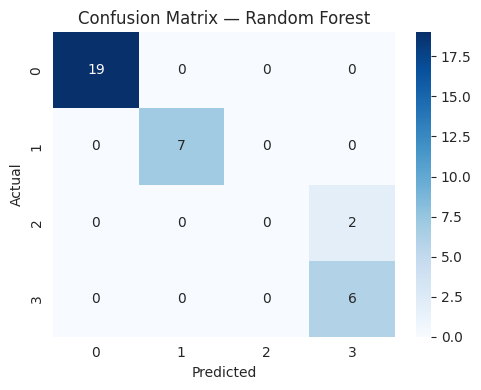

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

--- XGBoost ---
Accuracy: 0.882 | Precision: 0.831 | Recall: 0.882 | F1: 0.855
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        19
           1       0.86      0.86      0.86         7
           2       0.00      0.00      0.00         2
           3       0.86      1.00      0.92         6

    accuracy                           0.88        34
   macro avg       0.65      0.70      0.68        34
weighted avg       0.83      0.88      0.86        34



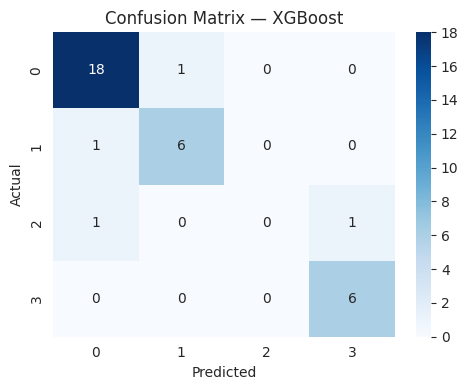

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

--- Ensemble (Voting) ---
Accuracy: 0.941 | Precision: 0.888 | Recall: 0.941 | F1: 0.913
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      1.00      1.00         7
           2       0.00      0.00      0.00         2
           3       0.86      1.00      0.92         6

    accuracy                           0.94        34
   macro avg       0.70      0.75      0.72        34
weighted avg       0.89      0.94      0.91        34



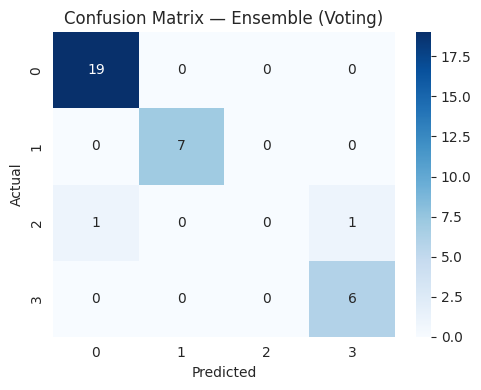

,accuracy,precision,recall,f1
Random Forest,0.941176,0.897059,0.941176,0.915966
XGBoost,0.882353,0.830672,0.882353,0.855204
Ensemble (Voting),0.941176,0.888025,0.941176,0.913273


In [22]:
def evaluate(y_test, y_pred, name):
    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted")
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.3f} | Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    save_current_fig(f"confusion_matrix_{safe_name}.png")
    plt.show()
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

results = {}
results["Random Forest"] = evaluate(y_test, y_pred_rf, "Random Forest")
if xgb_best is not None:
    results["XGBoost"] = evaluate(y_test, y_pred_xgb, "XGBoost")
if voting is not None:
    results["Ensemble (Voting)"] = evaluate(y_test, y_pred_vote, "Ensemble (Voting)")

pd.DataFrame(results).T


### 9a. Cross-validation (don't trust a single train/test split)

A single 80/20 split can make one model look better purely by luck of which countries land in the
test set. Run 5-fold CV and compare **mean ± standard deviation** — lower std deviation means a
more stable, trustworthy model, which matters more than a marginally higher mean.

In [23]:
rf_cv = cross_val_score(rf_best, X_scaled, df["segment"], cv=5, scoring="f1_weighted")
print(f"Random Forest CV F1: {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")

if xgb_best is not None:
    xgb_cv = cross_val_score(xgb_best, X_scaled, df["segment"], cv=5, scoring="f1_weighted")
    print(f"XGBoost CV F1:       {xgb_cv.mean():.3f} ± {xgb_cv.std():.3f}")


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Random Forest CV F1: 0.956 ± 0.027


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


XGBoost CV F1:       0.923 ± 0.026


### 9b. Is the difference between RF and XGBoost actually significant?

A paired t-test on the CV fold scores tells you whether one model is *meaningfully* better, or if
the difference is just noise. If `p > 0.05`, the honest conclusion is "no statistically significant
difference between the two models on this dataset" — which is a perfectly valid, defensible
finding, not a failure.

In [24]:
if xgb_best is not None:
    t_stat, p_value = stats.ttest_rel(rf_cv, xgb_cv)
    print(f"Paired t-test: t={t_stat:.3f}, p={p_value:.3f}")
    if p_value > 0.05:
        print("-> No statistically significant difference between Random Forest and XGBoost.")
    else:
        print("-> Statistically significant difference detected.")


Paired t-test: t=1.724, p=0.160
-> No statistically significant difference between Random Forest and XGBoost.


### 9c. Did the ensemble actually earn its complexity?

The ensemble should be judged against the **best individual model**, not the average of the two.
If the ensemble's F1 doesn't beat the stronger of RF/XGBoost, that's worth reporting honestly
rather than overclaiming that ensembling improved performance.

In [25]:
best_individual = max(results.get("Random Forest", {}).get("f1", 0),
                      results.get("XGBoost", {}).get("f1", 0))
ensemble_f1 = results.get("Ensemble (Voting)", {}).get("f1", None)

if ensemble_f1 is not None:
    if ensemble_f1 > best_individual:
        print(f"Ensemble F1 ({ensemble_f1:.3f}) beats best individual model ({best_individual:.3f}) — ensembling helped.")
    else:
        print(f"Ensemble F1 ({ensemble_f1:.3f}) did NOT beat best individual model ({best_individual:.3f}) — report this honestly.")


Ensemble F1 (0.913) did NOT beat best individual model (0.916) — report this honestly.


## 10. Feature Importance — Which Signals Actually Drive Segmentation?

This is where the "actionable insight" part of the project comes from: knowing *which* indicators
matter most tells a business (or an aid organization, for this dataset) where to focus attention or
intervention.

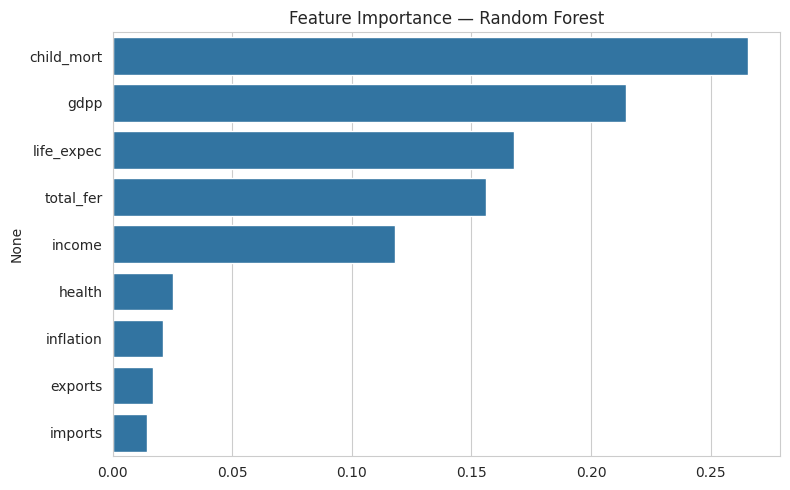

child_mort    0.265720
gdpp          0.214731
life_expec    0.167924
total_fer     0.156121
income        0.118003
health        0.025399
inflation     0.021118
exports       0.016732
imports       0.014252
dtype: float64


In [26]:
def plot_importance(model, name):
    if not hasattr(model, "feature_importances_"):
        return
    imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=imp.values, y=imp.index)
    plt.title(f"Feature Importance — {name}")
    plt.tight_layout()
    save_current_fig(f"feature_importance_{name.lower().replace(' ', '_')}.png")
    plt.show()
    return imp

rf_importance = plot_importance(rf_best, "Random Forest")
print(rf_importance)


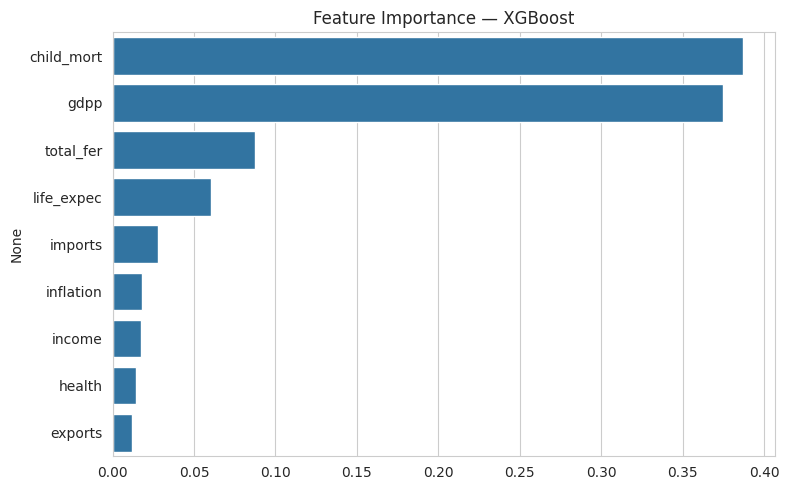

child_mort    0.387222
gdpp          0.374774
total_fer     0.087624
life_expec    0.060616
imports       0.028042
inflation     0.018057
income        0.017326
health        0.014483
exports       0.011856
dtype: float32


In [27]:
if xgb_best is not None:
    xgb_importance = plot_importance(xgb_best, "XGBoost")
    print(xgb_importance)


## 11. Final Segmented Output & Insights

Save the final table (country, cluster, human-readable segment name) — this is the deliverable a
business stakeholder would actually use.

In [28]:
output_cols = ["country"] + feature_cols + ["segment", "segment_name"]
df[output_cols].to_csv("customer_intelligence_output.csv", index=False)
print("Saved to customer_intelligence_output.csv")
df[output_cols].head(10)


Saved to customer_intelligence_output.csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,segment,segment_name
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,1,Segment 0
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,0,Segment 2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,0,Segment 2
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,1,Segment 0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,0,Segment 2
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,0,Segment 2
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,0,Segment 2
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,3,Segment 3
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,3,Segment 3
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840,0,Segment 2


In [29]:
import shutil

# Zip the plots folder
shutil.make_archive('plots', 'zip', 'plots')
print('plots.zip created.')

plots.zip created.


In [30]:
from google.colab import files

# Download the zipped plots folder
files.download('plots.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Summary of findings (fill in after running on the real dataset)

- **Chosen k:** _(from Section 5)_
- **K-Means vs DBSCAN agreement (ARI):** _(from Section 6b)_ — high agreement supports trusting the segments
- **Best classifier:** _(from Section 9)_, justified by weighted F1 + CV stability, not raw accuracy alone
- **Statistical significance (RF vs XGBoost):** _(from Section 9b)_
- **Did the ensemble help?** _(from Section 9c)_
- **Top drivers of segment membership:** _(from Section 10)_ — this is your actionable business insight
- **Outlier countries (DBSCAN noise):** _(from Section 6)_ — worth a special mention as edge cases

**Real-world translation:** replace `country` with `customer_id` and the socio-economic columns with
behavioral features (recency, frequency, monetary value, engagement score, support tickets, etc.)
and this exact pipeline becomes a production customer segmentation + scoring system.
